In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("D:/MY PROJECTS/Python/assiment python/large_sales_data.csv")

In [15]:
#First 5 rows
print(df.head())

         Date Region SalesPerson   Product  UnitsSold  UnitPrice
0  2024-01-01  South        John    Tablet         14        150
1  2024-01-01  North         Sam   Monitor          7        300
2  2024-01-01  South        John  Keyboard         11        100
3  2024-01-02  South         Ali    Laptop         12        150
4  2024-01-02   West        John    Tablet         11        100


In [19]:
#Data types of easch column
print(df.dtypes)

Date           object
Region         object
SalesPerson    object
Product        object
UnitsSold       int64
UnitPrice       int64
dtype: object


In [21]:
#Check missing values
print(df.isnull().sum())

Date           0
Region         0
SalesPerson    0
Product        0
UnitsSold      0
UnitPrice      0
dtype: int64


In [25]:
#Create anew column TotalRevenue
df["TotalRevenue"] = df["UnitsSold"]*df["UnitPrice"]
print(df.head())

         Date Region SalesPerson   Product  UnitsSold  UnitPrice  TotalRevenue
0  2024-01-01  South        John    Tablet         14        150          2100
1  2024-01-01  North         Sam   Monitor          7        300          2100
2  2024-01-01  South        John  Keyboard         11        100          1100
3  2024-01-02  South         Ali    Laptop         12        150          1800
4  2024-01-02   West        John    Tablet         11        100          1100


In [27]:
#Create anew column HighSale
df["HighSale"] = df["TotalRevenue"] > 3000
print(df.head())

         Date Region SalesPerson   Product  UnitsSold  UnitPrice  \
0  2024-01-01  South        John    Tablet         14        150   
1  2024-01-01  North         Sam   Monitor          7        300   
2  2024-01-01  South        John  Keyboard         11        100   
3  2024-01-02  South         Ali    Laptop         12        150   
4  2024-01-02   West        John    Tablet         11        100   

   TotalRevenue  HighSale  
0          2100     False  
1          2100     False  
2          1100     False  
3          1800     False  
4          1100     False  


In [31]:
#Total Revenue per sales person
total_revenue_per_salesperson = df.groupby("SalesPerson")["TotalRevenue"].sum()
print(total_revenue_per_salesperson)

SalesPerson
Ali       76300
John      95650
Laila     98250
Mona      95150
Sam      126900
Name: TotalRevenue, dtype: int64


In [37]:
#Average unitssold per region
average_unitssold_per_region = df.groupby("Region")["UnitsSold"].mean()
print(average_unitssold_per_region)

Region
East     7.134615
North    8.531915
South    7.980000
West     8.137255
Name: UnitsSold, dtype: float64


In [43]:
#Total number of unitssold per product
units_per_product = df.groupby("Product")["UnitsSold"].sum()
print(units_per_product)

Product
Keyboard    410
Laptop      384
Monitor     444
Tablet      348
Name: UnitsSold, dtype: int64


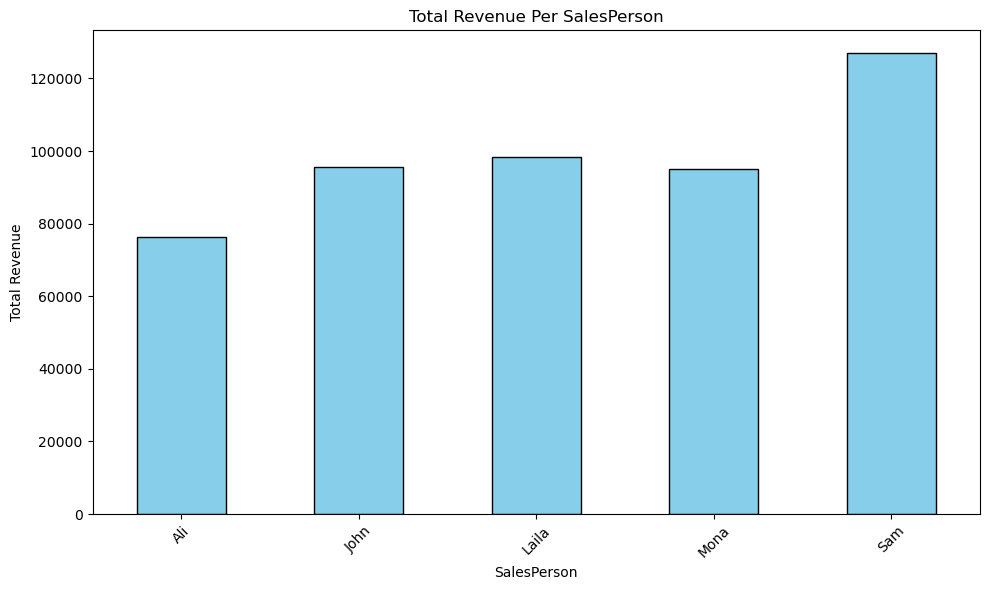

In [47]:
#Bar chart total revenue per sales person
plt.figure(figsize=(10, 6))
total_revenue_per_salesperson.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Total Revenue Per SalesPerson")
plt.xlabel("SalesPerson")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
           

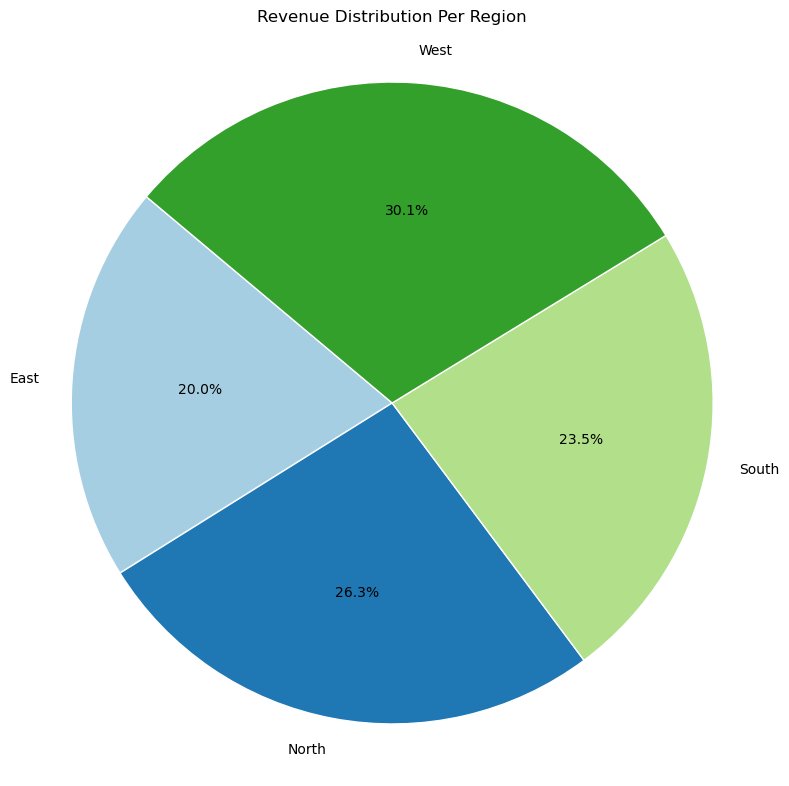

In [57]:
#Pie chart revenue distribution per region
total_revenue_per_region = df.groupby("Region")["TotalRevenue"].sum()
colors = plt.cm.Paired.colors
plt.figure(figsize=(8, 8))
plt.pie(total_revenue_per_region, 
        labels=total_revenue_per_region.index, 
        autopct="%1.1f%%", 
        startangle=140, 
        colors=colors, 
        wedgeprops={"edgecolor": "white", "linewidth": 1} )
plt.title("Revenue Distribution Per Region")
plt.axis("equal")
plt.tight_layout()
plt.show()

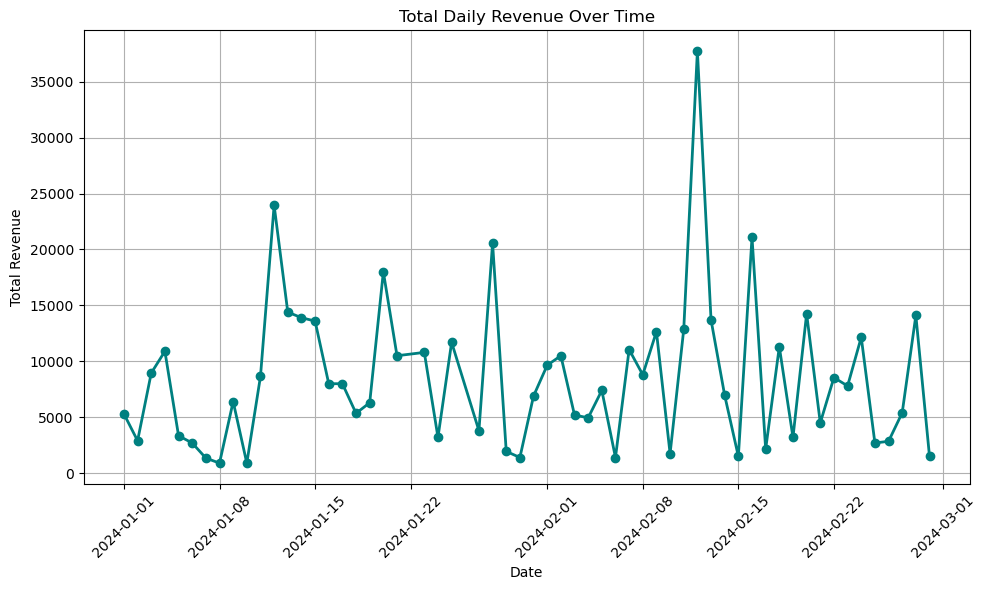

In [63]:
#Line chart total daily revenue groupby date
df["Date"] = pd.to_datetime(df["Date"])
daily_revenue = df.groupby("Date")["TotalRevenue"].sum()
plt.figure(figsize=(10, 6))
plt.plot(daily_revenue.index,
         daily_revenue.values,
         marker="o",
         linestyle="-",
         color="teal",
         linewidth=2,
         markersize=6)
plt.title("Total Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()